In [29]:
#IMPORTING lIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

#LOADING DATASET
student_df = pd.read_csv("../dataset/student_data.csv")

student_df.head()

,Student_ID,Attendance,Study_Hours,Assignment_Submission,Previous_Marks,Projects_Completed,Communication_Skills,Aptitude_Score,Internet_Access,Family_Support,Sleep_Hours,Outcome
0,1,88,2.1,Yes,40,4,8,59,Yes,Yes,8.2,Pass
1,2,78,4.6,Yes,89,4,6,97,Yes,Yes,7.6,Pass
2,3,64,5.9,Yes,82,1,6,88,Yes,Yes,8.0,Fail
3,4,92,7.0,Yes,38,0,7,100,Yes,Yes,6.0,Pass
4,5,57,3.3,No,64,3,4,98,Yes,Yes,7.3,Fail


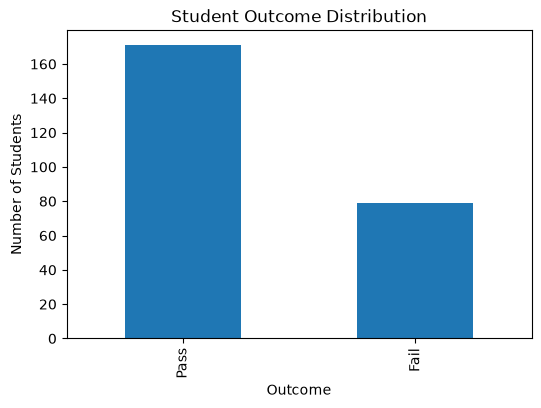

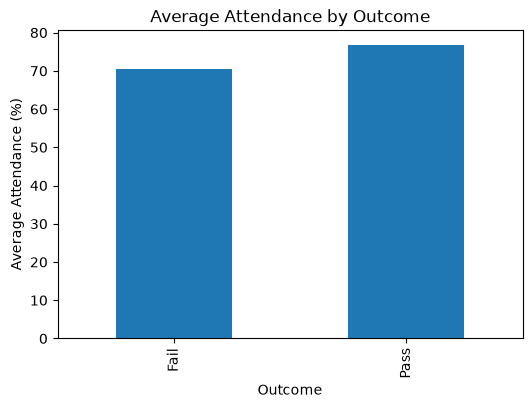

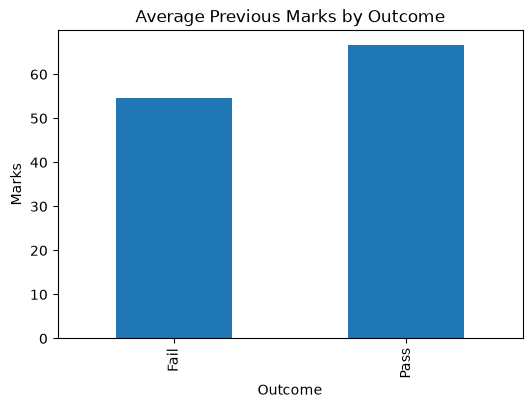

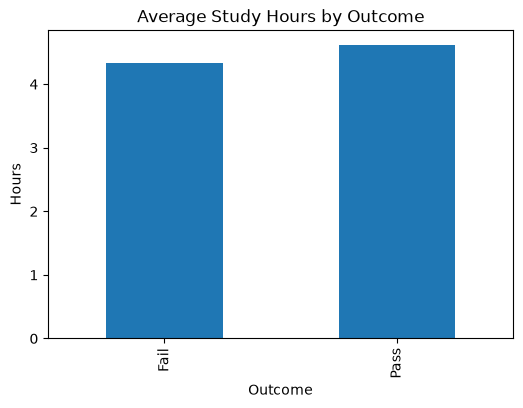

In [30]:
#EDA SECTION

#OUTCOME DISTRIBUTION
student_df["Outcome"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Student Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.show()

student_df.groupby("Outcome")["Attendance"].mean().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Average Attendance by Outcome")
plt.ylabel("Average Attendance (%)")
plt.show()

student_df.groupby("Outcome")["Previous_Marks"].mean().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Average Previous Marks by Outcome")
plt.ylabel("Marks")
plt.show()

student_df.groupby("Outcome")["Study_Hours"].mean().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Average Study Hours by Outcome")
plt.ylabel("Hours")
plt.show()

In [31]:
#CREATING CATEGORIAL VARIABLES
student_df["Assignment_Submission"] = student_df[
    "Assignment_Submission"
].map({"Yes": 1, "No": 0})

student_df["Internet_Access"] = student_df[
    "Internet_Access"
].map({"Yes": 1, "No": 0})

student_df["Family_Support"] = student_df[
    "Family_Support"
].map({"Yes": 1, "No": 0})

student_df["Outcome"] = student_df[
    "Outcome"
].map({"Pass": 1, "Fail": 0})

X = student_df.drop(
    columns=["Student_ID", "Outcome"]
)

y = student_df["Outcome"]

#USING TRAIN TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#FEATURE SCALING 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [ ]:
#LOGISTIC TRAINING
logistic_model = LogisticRegression(
    random_state=42 
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

#KNN TRAINING 
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

#SVM TRAINING
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

#DECISION TREE TRAINING
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(
    X_train,
    y_train
)

#PREDICITON
predictions = {
    "Logistic Regression": logistic_model.predict(X_test_scaled),
    "KNN": knn_model.predict(X_test_scaled),
    "SVM": svm_model.predict(X_test_scaled),
    "Decision Tree": decision_tree_model.predict(X_test)
}

In [ ]:
#MODEL SAVING 
joblib.dump(
    logistic_model,
    "../models/logistic_model.pkl"
)

joblib.dump(
    knn_model,
    "../models/knn_model.pkl"
)

joblib.dump(
    svm_model,
    "../models/svm_model.pkl"
)

joblib.dump(
    decision_tree_model,
    "../models/decision_tree_model.pkl"
)

['../models/decision_tree_model.pkl']

In [34]:
#MODEL COMPARISON
models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Decision Tree": decision_tree_model
}

results = []

for name, model in models.items():

    if name == "Decision Tree":
        cv_scores = cross_val_score(
            model,
            X,
            y,
            cv=5
        )
    else:
        cv_scores = cross_val_score(
            model,
            StandardScaler().fit_transform(X),
            y,
            cv=5
        )

    y_pred = predictions[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "CV Mean": cv_scores.mean()
    })

results = pd.DataFrame(results)

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [35]:
#CREATING TP TN FP FN
for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}")
    print("-" * 40)
    print("True Negative (TN):", tn)
    print("False Positive (FP):", fp)
    print("False Negative (FN):", fn)
    print("True Positive (TP):", tp)


Logistic Regression
----------------------------------------
True Negative (TN): 9
False Positive (FP): 7
False Negative (FN): 2
True Positive (TP): 32

KNN
----------------------------------------
True Negative (TN): 8
False Positive (FP): 8
False Negative (FN): 0
True Positive (TP): 34

SVM
----------------------------------------
True Negative (TN): 7
False Positive (FP): 9
False Negative (FN): 2
True Positive (TP): 32

Decision Tree
----------------------------------------
True Negative (TN): 7
False Positive (FP): 9
False Negative (FN): 11
True Positive (TP): 23


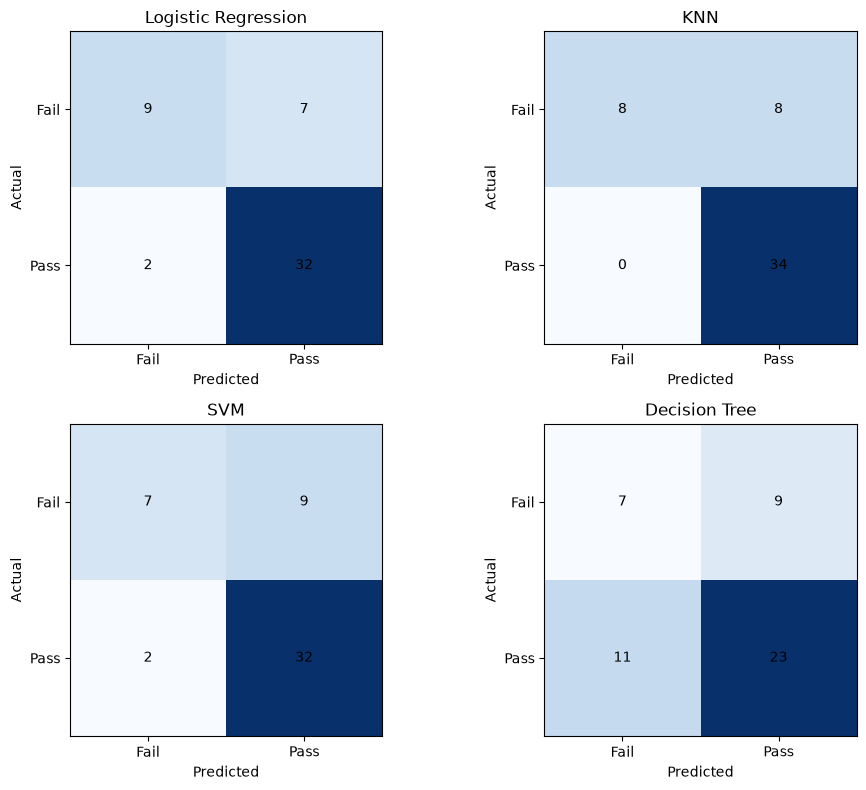

In [38]:
# CREATING CONFUSION MATRIX

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):

    cm = confusion_matrix(y_test, y_pred)

    ax.imshow(cm, cmap="Blues")

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Fail", "Pass"])
    ax.set_yticklabels(["Fail", "Pass"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()

# Save confusion matrix image
plt.savefig(
    "../images/confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# False Positive and False Negative Analysis

Since the target variable represents student outcome:

- **0 = Fail**
- **1 = Pass**

### True Positive (TP)
The model predicts **Pass**, and the student actually **Passes**.

### True Negative (TN)
The model predicts **Fail**, and the student actually **Fails**.

### False Positive (FP)
The model predicts **Pass**, but the student actually **Fails**.

This can be important because the student may not be identified as needing additional academic support.

### False Negative (FN)
The model predicts **Fail**, but the student actually **Passes**.

This may result in unnecessary academic intervention or additional support for a student who would have passed.

Therefore, both FP and FN should be considered when evaluating the model rather than relying only on accuracy.

In [37]:
#BEST MODEL SELECTION

best_model = results.iloc[0]

print(
    f"Best Model: {best_model['Model']} "
    f"with Accuracy = {best_model['Accuracy']:.2f}"
)

Best Model: KNN with Accuracy = 0.84


# Model Card

## Model Name
Student Outcome Prediction Model

## Purpose
This model predicts whether a student is likely to Pass or Fail based on academic and behavioral features.

## Dataset
The project uses a synthetic and anonymized dataset containing student academic and behavioral information.

## Input Features
- Attendance
- Study Hours
- Assignment Submission
- Previous Marks
- Projects Completed
- Communication Skills
- Aptitude Score
- Internet Access
- Family Support
- Sleep Hours

Student_ID is excluded from model training.

## Target
- Pass
- Fail

## Models Used
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree

## Evaluation Metrics
The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- 5-Fold Cross-Validation
- Confusion Matrix

## Best Model
The best-performing model is selected based on test-set accuracy and compared with the other models using multiple evaluation metrics.

## Intended Use
The model is intended to support educators in identifying students who may require additional academic assistance.

It should not replace human judgment or be used as the sole basis for academic decisions.

## Limitations
- The dataset is synthetic and may not represent all real-world student behavior.
- Important factors such as motivation, stress, health, and personal circumstances are not included.
- Performance may change when the model is applied to a different dataset.

## Ethical Limitations
Student data should be anonymized and securely stored.

The model may contain or learn biases from the training data. Predictions should therefore be monitored for unfair outcomes.

The model should not be used to label, punish, or discriminate against students.

Human oversight should always be maintained when using predictions for academic decisions.

## Ethical Limitations

This model should be used as a decision-support tool and not as the sole basis for academic decisions.

### Privacy
Student information should be anonymized and securely stored.

### Bias
The model may learn patterns or biases present in the training dataset. It should be evaluated regularly for unfair outcomes.

### Synthetic Dataset
The dataset used in this project is synthetic and may not fully represent real-world student behavior.

### Human Oversight
Teachers and academic advisors should make the final decisions. Model predictions should only assist them.

### Responsible Use
Predictions should be used to identify students who may benefit from additional support, not to label, punish, or discriminate against students.